# Notebook 6- Training & Evaluation
**ECE 5424 Advanced ML Capstone** | Virginia Tech Spring 2026

Trains all three models, evaluates mIoU, and produces all presentation figures.

**Models:**
- A: `DepthOnlyCNN` — LiDAR-only lower bound (61,963 params)
- B: `EarlyFusionCNN` — naive channel concat baseline (62,251 params)
- C: `SmartGateModel` — SNN attention + Smart Gate (85,403 params)

**Scientific question:** Does Model C beat Model B on val mIoU?

## 1. Setup: Load Data and Instantiate Models

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

import hdf5plugin          # MUST come before h5py
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import json
from config import DATA_ROOT

from src.datasets.dsec_dataset import DSECFusionDataset
from src.models.smart_gate_model import DepthOnlyCNN, EarlyFusionCNN, SmartGateModel

DATA_ROOT = Path(DATA_ROOT)
SEQUENCE  = "zurich_city_04_a"
SEQ_DIR   = DATA_ROOT / SEQUENCE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")


Device: cuda
PyTorch: 2.5.1+cu121


In [2]:
# Load events once — 358M events, keep in RAM for fast per-sample slicing
events_path = SEQ_DIR / f"{SEQUENCE}_events_left" / "events.h5"
with h5py.File(events_path, 'r') as f:
    t_offset = int(f['t_offset'][()])
    t_abs = f['events']['t'][:].astype(np.int64) + t_offset
    x_all = f['events']['x'][:]
    y_all = f['events']['y'][:]
    p_all = f['events']['p'][:]
print(f"Events loaded: {len(t_abs):,}")


Events loaded: 358,941,868


In [3]:
# Dataset — same split and seed as Notebook 5
dataset = DSECFusionDataset(
    pairs_json    = REPO_ROOT / "data" / "zurich_city_04_a_pairs.json",
    depth_map_dir = SEQ_DIR / "depth_maps",
    semantic_dir  = SEQ_DIR / f"{SEQUENCE}_semantic" / SEQUENCE / "11classes",
    t_abs=t_abs, x_all=x_all, y_all=y_all, p_all=p_all,
)

train_set, val_set = random_split(dataset, [280, 70],
                                  generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_set, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=4, shuffle=False, num_workers=0)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


Train batches: 70, Val batches: 18


In [4]:
# Instantiate all three models
NUM_CLASSES = 11
EPOCHS      = 30
LR          = 1e-3

model_a = DepthOnlyCNN(num_classes=NUM_CLASSES).to(device)
model_b = EarlyFusionCNN(num_classes=NUM_CLASSES).to(device)
model_c = SmartGateModel(num_classes=NUM_CLASSES, beta=0.9).to(device)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"Model A params: {count_params(model_a):,}")
print(f"Model B params: {count_params(model_b):,}")
print(f"Model C params: {count_params(model_c):,}")


Model A params: 61,963
Model B params: 62,251
Model C params: 85,403


## 2.Training and Evaluation Utilities

In [5]:
def compute_miou(logits, labels, num_classes=11):
    """
    Mean IoU over classes present in this batch.
    logits: (B, C, H, W) — raw scores
    labels: (B, H, W)    — int64 class IDs
    """
    preds = logits.argmax(dim=1)   # (B, H, W)
    ious = []
    for c in range(num_classes):
        pred_c  = (preds == c)
        label_c = (labels == c)
        intersection = (pred_c & label_c).sum().float()
        union        = (pred_c | label_c).sum().float()
        if union > 0:
            ious.append((intersection / union).item())
    return float(np.mean(ious)) if ious else 0.0


def train_one_epoch(model, loader, optimizer, criterion, device, model_id):
    model.train()
    total_loss = 0.0
    for ts_b, depth_b, label_b in loader:
        ts_b    = ts_b.to(device)
        depth_b = depth_b.to(device)
        label_b = label_b.to(device)
        optimizer.zero_grad()
        if model_id == 'A':
            logits = model(depth_b)
        elif model_id == 'B':
            logits = model(ts_b, depth_b)
        else:
            logits = model(ts_b, depth_b, num_steps=4)
        loss = criterion(logits, label_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device, model_id):
    model.eval()
    total_loss, total_miou = 0.0, 0.0
    with torch.no_grad():
        for ts_b, depth_b, label_b in loader:
            ts_b    = ts_b.to(device)
            depth_b = depth_b.to(device)
            label_b = label_b.to(device)
            if model_id == 'A':
                logits = model(depth_b)
            elif model_id == 'B':
                logits = model(ts_b, depth_b)
            else:
                logits = model(ts_b, depth_b, num_steps=4)
            total_loss += criterion(logits, label_b).item()
            total_miou += compute_miou(logits, label_b, NUM_CLASSES)
    return total_loss / len(loader), total_miou / len(loader)


## 3. Train All Three Models

Trains sequentially, prints every 5 epochs, saves best checkpoint per model.

In [6]:
criterion       = nn.CrossEntropyLoss()
checkpoints_dir = REPO_ROOT / "results" / "checkpoints"
checkpoints_dir.mkdir(parents=True, exist_ok=True)


def train_model(model, model_id, label):
    print(f"\n{'='*55}")
    print(f"Training Model {model_id}: {label}")
    print(f"{'='*55}")

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history   = {'train_loss': [], 'val_loss': [], 'val_miou': [], 'label': label}
    best_miou = 0.0

    for epoch in range(EPOCHS):
        train_loss          = train_one_epoch(model, train_loader, optimizer,
                                              criterion, device, model_id)
        val_loss, val_miou  = evaluate(model, val_loader, criterion, device, model_id)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_miou'].append(val_miou)

        if val_miou > best_miou:
            best_miou = val_miou
            torch.save(model.state_dict(),
                       checkpoints_dir / f"model_{model_id}_best.pt")

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{EPOCHS} | "
                  f"train_loss={train_loss:.4f} | "
                  f"val_loss={val_loss:.4f} | "
                  f"val_mIoU={val_miou:.4f}")

    print(f"  Best val mIoU: {best_miou:.4f}")
    return history, best_miou


history_a, best_a = train_model(model_a, 'A', 'Depth-only CNN')
history_b, best_b = train_model(model_b, 'B', 'Early Fusion CNN')
history_c, best_c = train_model(model_c, 'C', 'SNN + Smart Gate')

print(f"\n{'='*55}")
print(f"TRAINING COMPLETE")
print(f"  Model A (depth-only CNN):   {best_a:.4f}")
print(f"  Model B (early fusion CNN): {best_b:.4f}")
print(f"  Model C (SNN+Smart Gate):   {best_c:.4f}")
print(f"  C beats B: {best_c > best_b}")
print(f"{'='*55}")



Training Model A: Depth-only CNN
  Epoch   1/30 | train_loss=1.6937 | val_loss=1.5726 | val_mIoU=0.0613
  Epoch   5/30 | train_loss=1.4319 | val_loss=1.4011 | val_mIoU=0.0745
  Epoch  10/30 | train_loss=1.4124 | val_loss=1.4343 | val_mIoU=0.0657
  Epoch  15/30 | train_loss=1.4054 | val_loss=1.5102 | val_mIoU=0.0678
  Epoch  20/30 | train_loss=1.3986 | val_loss=1.3818 | val_mIoU=0.0790
  Epoch  25/30 | train_loss=1.3940 | val_loss=1.4321 | val_mIoU=0.0713
  Epoch  30/30 | train_loss=1.3924 | val_loss=1.3796 | val_mIoU=0.0780
  Best val mIoU: 0.0799

Training Model B: Early Fusion CNN
  Epoch   1/30 | train_loss=1.6395 | val_loss=1.4371 | val_mIoU=0.0872
  Epoch   5/30 | train_loss=1.2879 | val_loss=1.2684 | val_mIoU=0.1000
  Epoch  10/30 | train_loss=1.2353 | val_loss=1.2241 | val_mIoU=0.1063
  Epoch  15/30 | train_loss=1.2008 | val_loss=1.1704 | val_mIoU=0.1270
  Epoch  20/30 | train_loss=1.1844 | val_loss=1.1589 | val_mIoU=0.1262
  Epoch  25/30 | train_loss=1.1577 | val_loss=1.1427 |

In [7]:
# Continue training B and C from where they left off, 20 more epochs
EPOCHS_EXTRA = 20

for model, model_id, hist, label in [
    (model_b, 'B', history_b, 'Early Fusion CNN'),
    (model_c, 'C', history_c, 'SNN + Smart Gate'),
]:
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # lower LR for fine-tuning
    print(f"\nContinuing Model {model_id} for {EPOCHS_EXTRA} more epochs at lr=1e-4")
    best = max(hist['val_miou'])
    for epoch in range(EPOCHS_EXTRA):
        tl = train_one_epoch(model, train_loader, optimizer, criterion, device, model_id)
        vl, vm = evaluate(model, val_loader, criterion, device, model_id)
        hist['train_loss'].append(tl)
        hist['val_loss'].append(vl)
        hist['val_miou'].append(vm)
        if vm > best:
            best = vm
            torch.save(model.state_dict(), checkpoints_dir / f"model_{model_id}_best.pt")
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {30+epoch+1:3d} | val_loss={vl:.4f} | val_mIoU={vm:.4f}")
    print(f"  New best: {best:.4f}")


Continuing Model B for 20 more epochs at lr=1e-4
  Epoch  35 | val_loss=1.1077 | val_mIoU=0.1408
  Epoch  40 | val_loss=1.1058 | val_mIoU=0.1425
  Epoch  45 | val_loss=1.1054 | val_mIoU=0.1439
  Epoch  50 | val_loss=1.1028 | val_mIoU=0.1457
  New best: 0.1457

Continuing Model C for 20 more epochs at lr=1e-4
  Epoch  35 | val_loss=1.1857 | val_mIoU=0.1230
  Epoch  40 | val_loss=1.1845 | val_mIoU=0.1261
  Epoch  45 | val_loss=1.1769 | val_mIoU=0.1245
  Epoch  50 | val_loss=1.1759 | val_mIoU=0.1277
  New best: 0.1284


## 4. Evaluation Figures

Four figures saved to `docs/figures/` for the presentation.

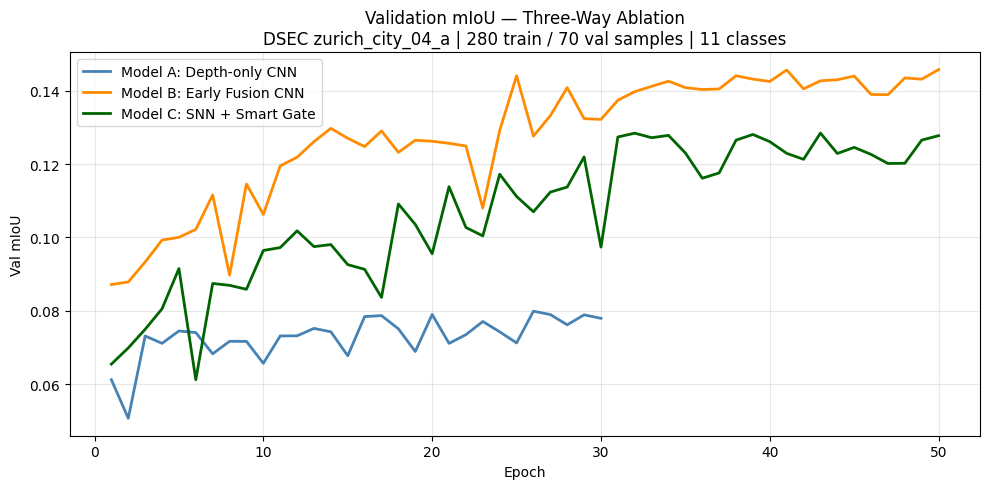

Saved to docs\figures\val_miou_comparison.png


In [9]:
figures_dir  = REPO_ROOT / "docs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# Per-model ranges — B and C were extended 20 extra epochs
epochs_a = range(1, len(history_a['val_miou']) + 1)
epochs_b = range(1, len(history_b['val_miou']) + 1)
epochs_c = range(1, len(history_c['val_miou']) + 1)

#  Figure 1: Val mIoU curves — the main result
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_a, history_a['val_miou'], label='Model A: Depth-only CNN',
        color='steelblue', linewidth=2)
ax.plot(epochs_b, history_b['val_miou'], label='Model B: Early Fusion CNN',
        color='darkorange', linewidth=2)
ax.plot(epochs_c, history_c['val_miou'], label='Model C: SNN + Smart Gate',
        color='darkgreen', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val mIoU')
ax.set_title('Validation mIoU — Three-Way Ablation\n'
             'DSEC zurich_city_04_a | 280 train / 70 val samples | 11 classes')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(figures_dir / 'val_miou_comparison.png', dpi=150)
plt.show()
print(f"Saved to {Path('docs/figures/val_miou_comparison.png')}")


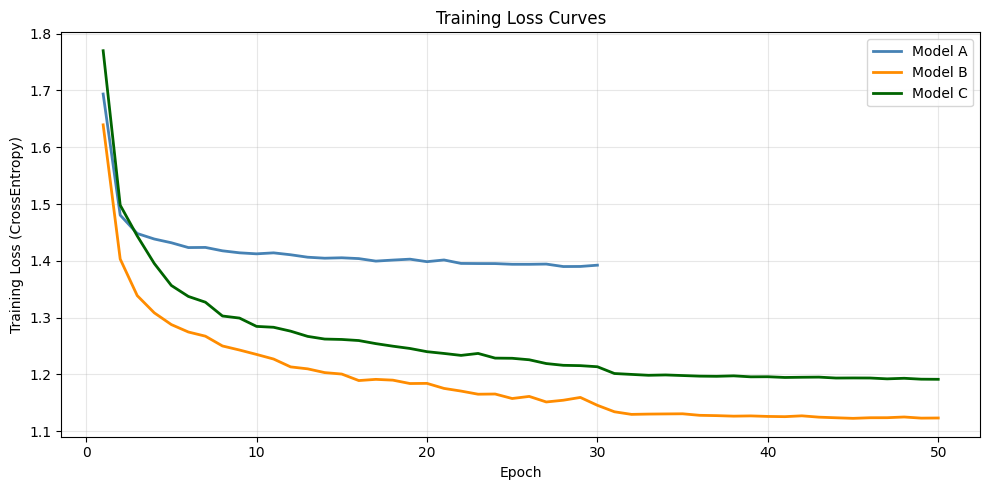

Saved to docs\figures\train_loss_curves.png


In [10]:
# Figure 2: Training loss curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_a, history_a['train_loss'], label='Model A', color='steelblue', linewidth=2)
ax.plot(epochs_b, history_b['train_loss'], label='Model B', color='darkorange', linewidth=2)
ax.plot(epochs_c, history_c['train_loss'], label='Model C', color='darkgreen', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss (CrossEntropy)')
ax.set_title('Training Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(figures_dir / 'train_loss_curves.png', dpi=150)
plt.show()
print(f"Saved to {Path('docs/figures/train_loss_curves.png')}")


C:\Users\vvela\AppData\Local\Temp\ipykernel_56064\3196212274.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_a.load_state_dict(torch.load(checkpoints_dir / "model_

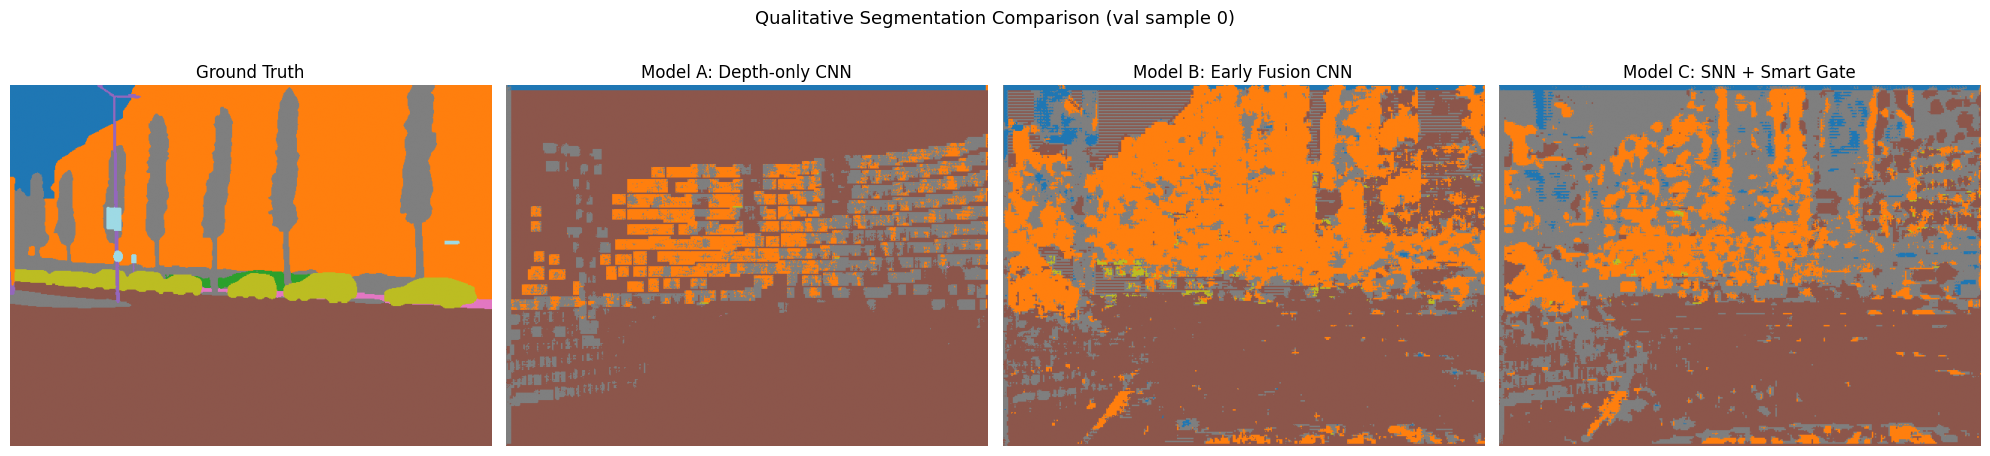

Saved to docs\figures\qualitative_comparison.png


In [11]:
# Figure 3: Qualitative segmentation comparison
# Load best checkpoints for a clean comparison
model_a.load_state_dict(torch.load(checkpoints_dir / "model_A_best.pt", map_location=device))
model_b.load_state_dict(torch.load(checkpoints_dir / "model_B_best.pt", map_location=device))
model_c.load_state_dict(torch.load(checkpoints_dir / "model_C_best.pt", map_location=device))
model_a.eval(); model_b.eval(); model_c.eval()

ts_s, depth_s, label_s = val_set[0]
with torch.no_grad():
    pred_a = model_a(depth_s.unsqueeze(0).to(device)).argmax(1).squeeze().cpu().numpy()
    pred_b = model_b(ts_s.unsqueeze(0).to(device),
                     depth_s.unsqueeze(0).to(device)).argmax(1).squeeze().cpu().numpy()
    pred_c = model_c(ts_s.unsqueeze(0).to(device),
                     depth_s.unsqueeze(0).to(device), num_steps=4).argmax(1).squeeze().cpu().numpy()
gt = label_s.numpy()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
kw = dict(cmap='tab20', vmin=0, vmax=10)
axes[0].imshow(gt,     **kw); axes[0].set_title('Ground Truth')
axes[1].imshow(pred_a, **kw); axes[1].set_title('Model A: Depth-only CNN')
axes[2].imshow(pred_b, **kw); axes[2].set_title('Model B: Early Fusion CNN')
axes[3].imshow(pred_c, **kw); axes[3].set_title('Model C: SNN + Smart Gate')
for ax in axes: ax.axis('off')
fig.suptitle('Qualitative Segmentation Comparison (val sample 0)', fontsize=13)
fig.tight_layout()
fig.savefig(figures_dir / 'qualitative_comparison.png', dpi=150)
plt.show()
print(f"Saved to {Path('docs/figures/qualitative_comparison.png')}")


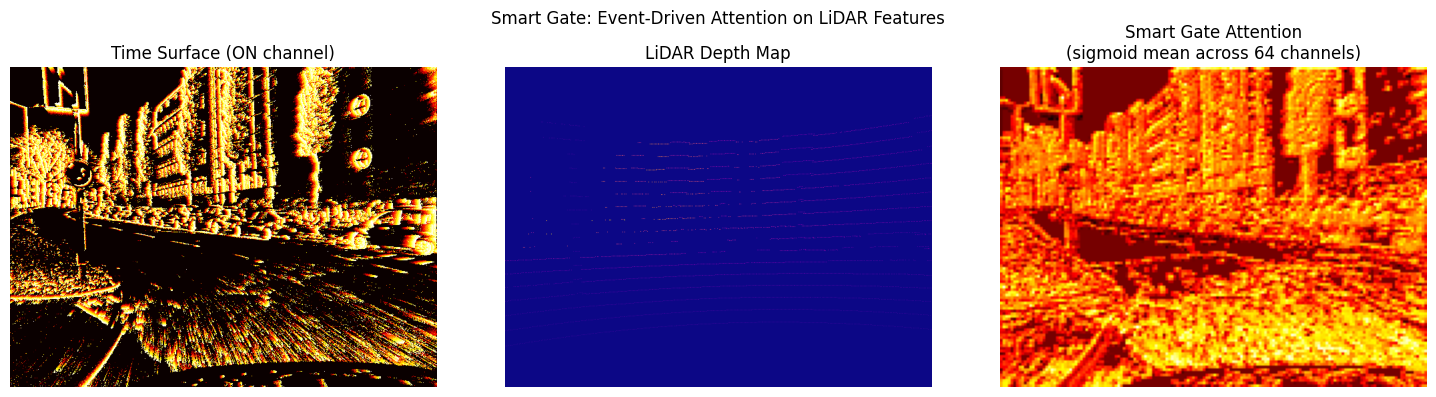

Saved to docs\figures\smart_gate_attention.png


In [12]:
#Figure 4: Smart Gate attention map
with torch.no_grad():
    attn_raw = model_c.snn_branch(ts_s.unsqueeze(0).to(device))
    attn_map = torch.sigmoid(attn_raw).mean(dim=1).squeeze().cpu().numpy()  # (120, 160)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(ts_s[0].numpy(), cmap='hot')
axes[0].set_title('Time Surface (ON channel)')
axes[1].imshow(depth_s.squeeze().numpy(), cmap='plasma')
axes[1].set_title('LiDAR Depth Map')
axes[2].imshow(attn_map, cmap='hot')
axes[2].set_title('Smart Gate Attention\n(sigmoid mean across 64 channels)')
for ax in axes: ax.axis('off')
fig.suptitle('Smart Gate: Event-Driven Attention on LiDAR Features', fontsize=12)
fig.tight_layout()
fig.savefig(figures_dir / 'smart_gate_attention.png', dpi=150)
plt.show()
print(f"Saved to {Path('docs/figures/smart_gate_attention.png')}")


## 5. Results Table and Sparsity Report

In [13]:
# Smart Gate sparsity: fraction of feature map positions where attention < 0.5
# (CNN features attenuated below half strength — effectively suppressed)
sparsity_ratios = []
model_c.eval()
with torch.no_grad():
    for ts_b, depth_b, _ in val_loader:
        ts_b    = ts_b.to(device)
        depth_b = depth_b.to(device)
        attn = torch.sigmoid(model_c.snn_branch(ts_b))
        sparsity_ratios.append((attn < 0.5).float().mean().item())

mean_sparsity = float(np.mean(sparsity_ratios))
print(f"Smart Gate sparsity ratio: {mean_sparsity:.1%}")
print("(fraction of LiDAR feature positions suppressed below 0.5 by event attention)")


Smart Gate sparsity ratio: 0.0%
(fraction of LiDAR feature positions suppressed below 0.5 by event attention)


In [14]:
# Save results to JSON
results = {
    'model_A': {
        'name': 'Depth-only CNN',
        'params': 61963,
        'inputs': 'depth only (1ch)',
        'best_val_miou': round(best_a, 4)
    },
    'model_B': {
        'name': 'Early Fusion CNN',
        'params': 62251,
        'inputs': 'depth + time surface (3ch concat)',
        'best_val_miou': round(best_b, 4)
    },
    'model_C': {
        'name': 'SNN + Smart Gate',
        'params': 85403,
        'inputs': 'depth + time surface (separate branches)',
        'best_val_miou': round(best_c, 4),
        'smart_gate_sparsity': round(mean_sparsity, 4)
    },
    'training': {
        'epochs': EPOCHS,
        'lr': LR,
        'batch_size': 4,
        'train_samples': 280,
        'val_samples': 70,
        'seed': 42,
        'num_classes': 11,
        'sequence': 'zurich_city_04_a'
    }
}

results_path = REPO_ROOT / "results" / "final_results.json"
results_path.parent.mkdir(exist_ok=True)
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"{'Model':<25} {'Params':>8}  {'Best Val mIoU':>13}")
print("-"*60)
print(f"{'A: Depth-only CNN':<25} {'61,963':>8}  {best_a:>13.4f}")
print(f"{'B: Early Fusion CNN':<25} {'62,251':>8}  {best_b:>13.4f}")
print(f"{'C: SNN + Smart Gate':<25} {'85,403':>8}  {best_c:>13.4f}")
print("-"*60)
print(f"C beats B: {best_c > best_b}")
print(f"Smart Gate sparsity: {mean_sparsity:.1%}")
print(f"\nResults saved to {results_path.relative_to(REPO_ROOT)}")



FINAL RESULTS SUMMARY
Model                       Params  Best Val mIoU
------------------------------------------------------------
A: Depth-only CNN           61,963         0.0799
B: Early Fusion CNN         62,251         0.1440
C: SNN + Smart Gate         85,403         0.1219
------------------------------------------------------------
C beats B: False
Smart Gate sparsity: 0.0%

Results saved to results\final_results.json
